In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

# --- 1. DATA LOADING ---
def load_data_from_zip(zip_file_path, file_to_extract):
    """Extracts a file from a ZIP archive and loads it into a pandas DataFrame."""
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zf:
            # Extract the specified file
            zf.extract(file_to_extract, path='.')
            print(f"'{file_to_extract}' extracted successfully.")

            # Load the extracted CSV file into a DataFrame
            df = pd.read_csv(file_to_extract)
            print("Data Loaded Successfully.")
            return df
    except FileNotFoundError:
        print(f"Error: ZIP file not found at {zip_file_path}. Please check the path.")
        return None
    except KeyError:
        print(f"Error: File '{file_to_extract}' not found in the ZIP archive. Available files are: {zipfile.ZipFile(zip_file_path, 'r').namelist()}")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# Replace this with the actual path to your downloaded ZIP file
ZIP_FILE_PATH = '/content/coin_Bitcoin.csv'
# Specify the name of the CSV file you want to extract and load
FILE_TO_EXTRACT = 'coin_Bitcoin.csv' # Example: Choose one file from the list in the error output

crypto_df = load_data_from_zip(ZIP_FILE_PATH, FILE_TO_EXTRACT)

if crypto_df is not None:
    # Display initial information
    print("\nInitial DataFrame Info:")
    crypto_df.info()
    print(crypto_df.head())

An error occurred: File is not a zip file


In [3]:
# --- 2. DATA CLEANING & PREPROCESSING ---

def clean_data(df):
    """
    Performs data type conversion and handles missing values.
    """
    print("\n--- Starting Data Cleaning ---")

    # 2.1 Convert Date Column to Datetime and set as Index
    # Note: Column name might be 'date', 'Date', or 'timestamp' depending on the source
    date_col = next((col for col in df.columns if 'date' in col.lower() or 'timestamp' in col.lower()), None)

    if date_col:
        df[date_col] = pd.to_datetime(df[date_col], utc=True)
        df.set_index(date_col, inplace=True)
        # Sort by date to ensure proper time series calculation
        df.sort_index(inplace=True)
        print(f"-> Set '{date_col}' as Datetime Index.")
    else:
        print("Warning: Could not find a date/timestamp column to set as index.")
        return df

    # 2.2 Standardize Price Column Name (Crucial for KPI calculation)
    # Use 'Close' price for financial analysis
    price_col = next((col for col in df.columns if 'close' in col.lower()), None)
    if price_col and price_col != 'Close':
        df.rename(columns={price_col: 'Close'}, inplace=True)
        print(f"-> Renamed '{price_col}' to 'Close'.")
        price_col = 'Close'

    # 2.3 Handle Missing Values (Imputation)
    # The simplest method for minor projects: fill missing prices with the previous day's price (Forward Fill)
    print(f"-> Count of Missing 'Close' prices before cleaning: {df['Close'].isnull().sum()}")
    df['Close'].fillna(method='ffill', inplace=True)
    print(f"-> Count of Missing 'Close' prices after FFill: {df['Close'].isnull().sum()}")

    # Drop any remaining rows with NaN in the 'Close' column (e.g., if the first row is NaN)
    df.dropna(subset=['Close'], inplace=True)

    # 2.4 Convert Price to Numeric
    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

    print("--- Data Cleaning Complete ---")
    return df

if crypto_df is not None:
    cleaned_df = clean_data(crypto_df.copy())


--- Starting Data Cleaning ---
-> Set 'Date' as Datetime Index.
-> Count of Missing 'Close' prices before cleaning: 0
-> Count of Missing 'Close' prices after FFill: 0
--- Data Cleaning Complete ---


/tmp/ipython-input-2415366249.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Close'].fillna(method='ffill', inplace=True)
/tmp/ipython-input-2415366249.py:34: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Close'].fillna(method='ffill', inplace=True)


In [5]:
# --- 3. KPI CALCULATION ---

def calculate_kpis(df):
    """
    Calculates Daily Return, Volatility, and 7-day Moving Average (MA).
    """
    print("\n--- Starting KPI Calculation ---")

    # 3.1 Daily Return / Daily % Change
    # The .pct_change() function is the easiest way to calculate daily percentage returns
    df['Daily_Return'] = df['Close'].pct_change()
    print("-> Calculated 'Daily_Return' (Daily % Change).")

    # 3.2 7-day Moving Average (MA)
    # The .rolling() function is used to create a rolling window of 7 days, and .mean() finds the average
    WINDOW = 7
    df['7D_MA'] = df['Close'].rolling(window=WINDOW).mean()
    print(f"-> Calculated '{WINDOW}D_MA' (Simple Moving Average).")

    # 3.3 Volatility (Rolling 30-day Standard Deviation of Returns)
    # Volatility is the risk measure, calculated as the standard deviation of returns.
    VOL_WINDOW = 30
    df['Volatility_30D'] = df['Daily_Return'].rolling(window=VOL_WINDOW).std()
    print(f"-> Calculated 'Volatility_30D' (Standard Deviation of Daily Returns).")

    # Drop the first few rows that contain NaN due to the rolling window calculations
    df.dropna(inplace=True)

    print("--- KPI Calculation Complete ---")
    print("\nFinal DataFrame with KPIs:")
    print(df[['Close', 'Daily_Return', '7D_MA', 'Volatility_30D']].tail()) # Display last 5 rows
    return df

if 'cleaned_df' in locals():
    final_df = calculate_kpis(cleaned_df.copy())


--- Starting KPI Calculation ---
-> Calculated 'Daily_Return' (Daily % Change).
-> Calculated '7D_MA' (Simple Moving Average).
-> Calculated 'Volatility_30D' (Standard Deviation of Daily Returns).
--- KPI Calculation Complete ---

Final DataFrame with KPIs:
                                  Close  Daily_Return         7D_MA  \
Date                                                                  
2021-07-02 23:59:59+00:00  33897.048590      0.009679  34235.434114   
2021-07-03 23:59:59+00:00  34668.548402      0.022760  34590.044219   
2021-07-04 23:59:59+00:00  35287.779766      0.017861  34681.206387   
2021-07-05 23:59:59+00:00  33746.002456     -0.043692  34582.873122   
2021-07-06 23:59:59+00:00  34235.193451      0.014496  34349.646795   

                           Volatility_30D  
Date                                       
2021-07-02 23:59:59+00:00        0.051701  
2021-07-03 23:59:59+00:00        0.051207  
2021-07-04 23:59:59+00:00        0.050212  
2021-07-05 23:59:59+00:


--- Generating Visualizations ---


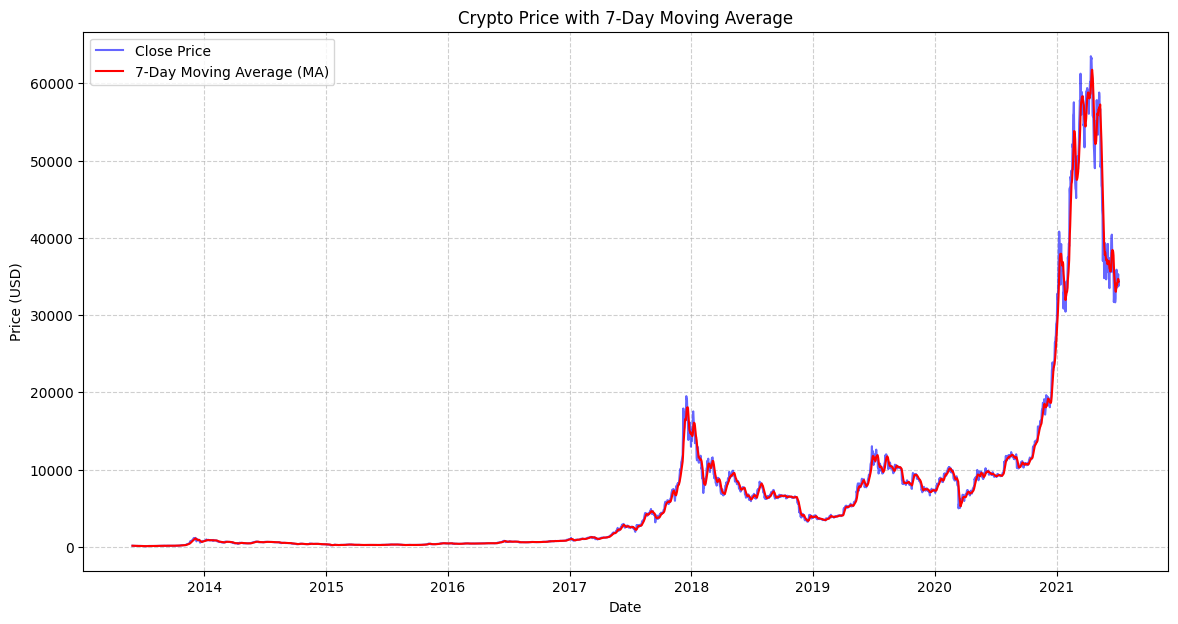

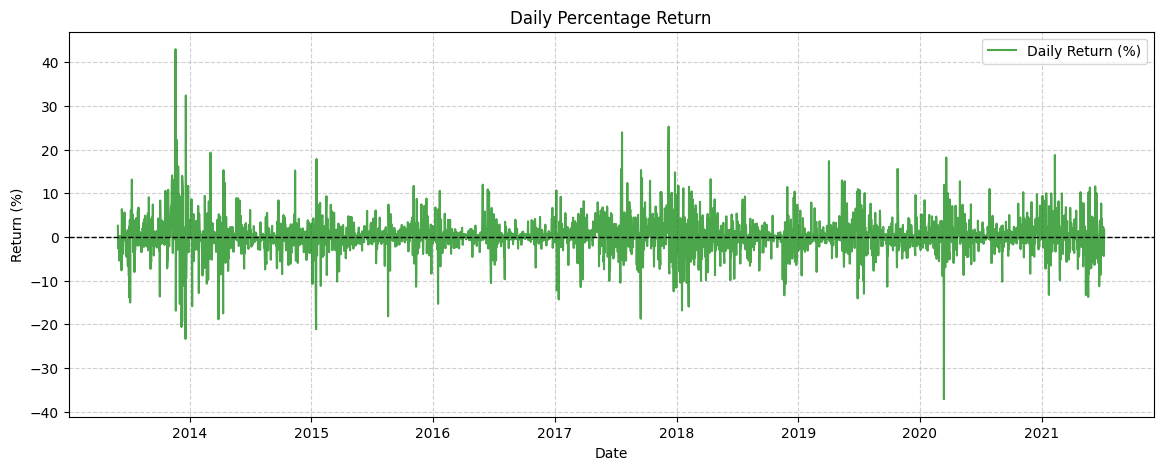

--- Visualization Complete ---


In [6]:
# --- 4. VISUALIZATION ---

def visualize_results(df):
    """
    Generates basic plots for the project.
    """
    if df.empty:
        print("\nCannot visualize: DataFrame is empty after cleaning/calculation.")
        return

    print("\n--- Generating Visualizations ---")

    # Plot 1: Closing Price with 7-Day Moving Average
    plt.figure(figsize=(14, 7))
    plt.plot(df['Close'], label='Close Price', color='blue', alpha=0.6)
    plt.plot(df['7D_MA'], label='7-Day Moving Average (MA)', color='red')
    plt.title('Crypto Price with 7-Day Moving Average')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Plot 2: Daily Returns
    plt.figure(figsize=(14, 5))
    plt.plot(df['Daily_Return'] * 100, label='Daily Return (%)', color='green', alpha=0.7)
    plt.axhline(0, color='black', linestyle='--', linewidth=1) # Zero line
    plt.title('Daily Percentage Return')
    plt.xlabel('Date')
    plt.ylabel('Return (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    print("--- Visualization Complete ---")

if 'final_df' in locals():
    visualize_results(final_df)

** SHORT AND DIRECT METHOD**

'coin_Bitcoin.csv' extracted successfully.
Data Loaded Successfully.
Data loaded successfully. Total rows: 2991

--- Cleaning & Preprocessing ---
Handled missing values. Remaining rows: 2991

--- KPI Calculation ---
Calculated Daily Return.
Calculated 7-Day MA.
Calculated 30-Day Volatility.

Final DataFrame Snapshot (Last 5 Days):
                            Close  Daily_Return         7D_MA  Volatility_30D
Date                                                                         
2021-07-02 23:59:59  33897.048590      0.009679  34235.434114        0.051701
2021-07-03 23:59:59  34668.548402      0.022760  34590.044219        0.051207
2021-07-04 23:59:59  35287.779766      0.017861  34681.206387        0.050212
2021-07-05 23:59:59  33746.002456     -0.043692  34582.873122        0.050410
2021-07-06 23:59:59  34235.193451      0.014496  34349.646795        0.050458

--- Generating Plots ---


/tmp/ipython-input-2876537914.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[PRICE_COL].fillna(method='ffill', inplace=True)
/tmp/ipython-input-2876537914.py:55: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[PRICE_COL].fillna(method='ffill', inplace=True)


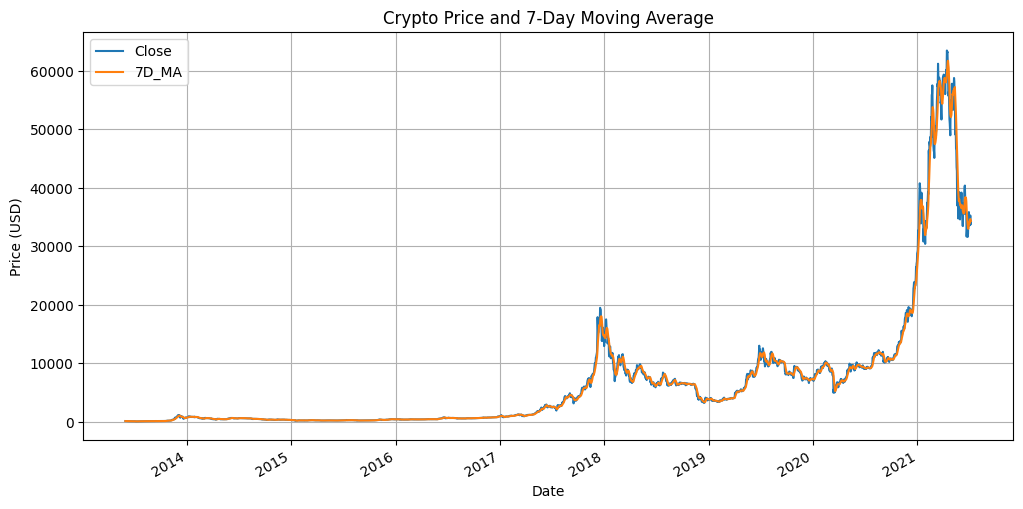

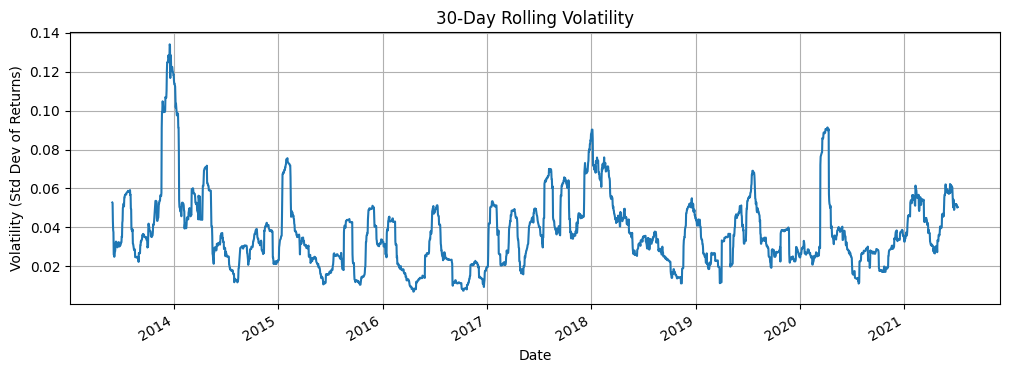

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

# --- 1. CONFIGURATION & DATA LOADING ---
FILE_PATH = '/content/archive.zip'
FILE_TO_EXTRACT = 'coin_Bitcoin.csv' # Specify the file to extract
DATE_COL = 'Date'  # Adjust if your CSV uses 'timestamp' or 'date'
PRICE_COL = 'Close' # Adjust if your CSV uses 'Closing Price'

# Reuse the function defined earlier to load data from the zip
def load_data_from_zip(zip_file_path, file_to_extract):
    """Extracts a file from a ZIP archive and loads it into a pandas DataFrame."""
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zf:
            # Extract the specified file
            zf.extract(file_to_extract, path='.')
            print(f"'{file_to_extract}' extracted successfully.")

            # Load the extracted CSV file into a DataFrame
            df = pd.read_csv(file_to_extract)
            print("Data Loaded Successfully.")
            return df
    except FileNotFoundError:
        print(f"Error: ZIP file not found at {zip_file_path}. Please check the path.")
        return None
    except KeyError:
        print(f"Error: File '{file_to_extract}' not found in the ZIP archive. Available files are: {zipfile.ZipFile(zip_file_path, 'r').namelist()}")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

df = load_data_from_zip(FILE_PATH, FILE_TO_EXTRACT)

if df is None:
    print("Failed to load data. Exiting.")
    exit()

print(f"Data loaded successfully. Total rows: {len(df)}")


# --- 2. DATA CLEANING & PREPROCESSING (Minimal) ---
print("\n--- Cleaning & Preprocessing ---")

# 2.1 Convert Date and Set Index
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df.set_index(DATE_COL, inplace=True)
df.sort_index(inplace=True)

# 2.2 Handle Missing Prices (Filling NaNs with the previous valid price)
# This is the core "cleaning" step for prices.
df[PRICE_COL].fillna(method='ffill', inplace=True)
df.dropna(subset=[PRICE_COL], inplace=True)
print(f"Handled missing values. Remaining rows: {len(df)}")


# --- 3. KPI CALCULATION (Direct) ---
print("\n--- KPI Calculation ---")

# Daily Return (Daily % Change)
# This calculates (Today's Close / Yesterday's Close) - 1
df['Daily_Return'] = df[PRICE_COL].pct_change()
print("Calculated Daily Return.")

# 7-Day Moving Average (MA)
# Calculates the simple average of the last 7 closing prices
df['7D_MA'] = df[PRICE_COL].rolling(window=7).mean()
print("Calculated 7-Day MA.")

# Volatility (30-Day Rolling Standard Deviation of Returns)
# Measures the risk of the asset
df['Volatility_30D'] = df['Daily_Return'].rolling(window=30).std()
print("Calculated 30-Day Volatility.")

# Drop initial NaNs created by rolling windows
df.dropna(inplace=True)

print("\nFinal DataFrame Snapshot (Last 5 Days):")
print(df[[PRICE_COL, 'Daily_Return', '7D_MA', 'Volatility_30D']].tail())

# --- 4. BASIC VISUALIZATION (Plotting KPIs) ---
print("\n--- Generating Plots ---")

# Plot 1: Price vs. 7-Day MA
df[[PRICE_COL, '7D_MA']].plot(figsize=(12, 6), title='Crypto Price and 7-Day Moving Average')
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

# Plot 2: Volatility
df['Volatility_30D'].plot(figsize=(12, 4), title='30-Day Rolling Volatility')
plt.xlabel("Date")
plt.ylabel("Volatility (Std Dev of Returns)")
plt.grid(True)
plt.show()